## Particle trapping in a dipole magnetic field
Julia Nordstrom

Spring 2026

This code creates a dipole magnetic field using PlasmaPy's MagneticDipole function, then initializes particles in the field and tracks their motion using the PlasmaPy ParticleTracker module. This code may be used to track a single particle or an ensemble of particles, with the option to manually input the starting conditions (position and velocity) or pick them randomly within a set range.

In [2]:
# imports
import matplotlib.pyplot as plt
%matplotlib ipympl
import numpy as np

import astropy.units as u
from plasmapy.particles import Particle
from plasmapy.plasma.grids import CartesianGrid
from plasmapy.simulation.particle_tracker.particle_tracker import ParticleTracker
from plasmapy.formulary.magnetostatics import MagneticDipole
from plasmapy.simulation.particle_tracker.termination_conditions import TimeElapsedTerminationCondition
from plasmapy.simulation.particle_tracker.save_routines import IntervalSaveRoutine

In [178]:
# input parameters for dipole
moment = 1*u.amp*u.m*u.m # sets magnetic moment of dipole
o = (0,0,0)*u.m # sets center of dipole

gridlength=50
gridstart =-5
gridend=5
grid = CartesianGrid(gridstart*u.m,gridend*u.m,num=gridlength)
xx=np.linspace(gridstart,gridend,gridlength)
yy=np.linspace(gridstart,gridend,gridlength)
zz=np.linspace(gridstart,gridend,gridlength)

dipole = MagneticDipole(moment,o) # initialize dipole
Bx = np.zeros(grid.shape) #initialize B array
By = np.zeros(grid.shape)
Bz = np.zeros(grid.shape)

for i in np.ndindex(grid.shape) :
    point = (grid.pts0.value[i],grid.pts1.value[i],grid.pts2.value[i]) # loop through points in grid
    B = dipole.magnetic_field(point) # create dipole field at point
    Bx[i] = B[0].value # assign components of field
    By[i] = B[1].value
    Bz[i] = B[2].value

Bx *= u.T # taking units off inside the loop then adding them all back later helps this run faster
By *= u.T
Bz *= u.T

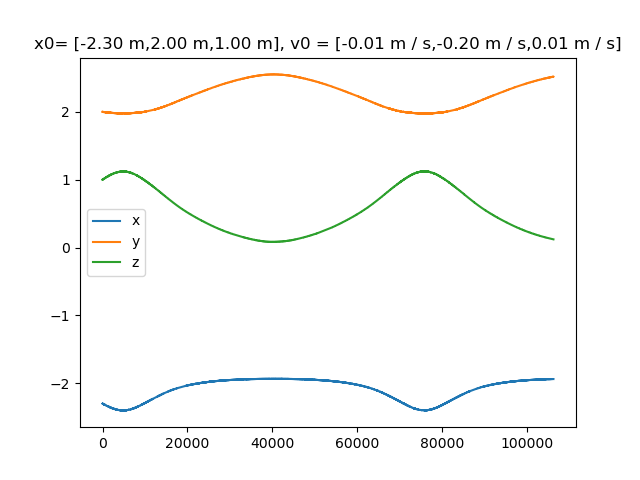

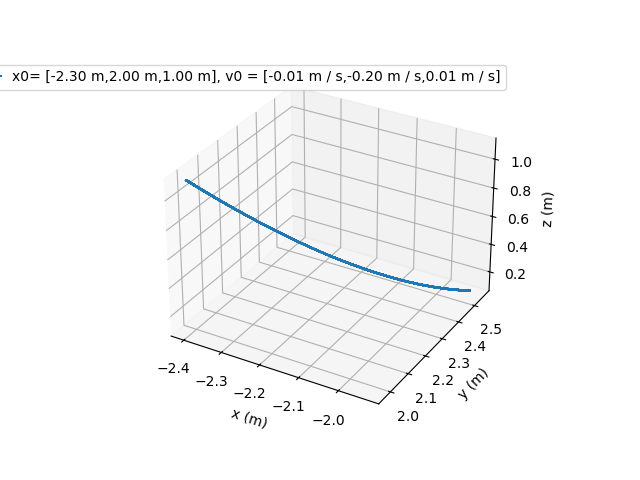

In [156]:
grid.add_quantities(B_x=Bx,B_y=By,B_z=Bz)
fig = plt.figure(45) # initialize 3d plot with all particle trajectories
plt.clf()
ax = fig.add_subplot(projection='3d')
for i in np.arange(1) : # change number in loop to change the number of initialized particles
    
    termination_condition = TimeElapsedTerminationCondition(90*u.s) 
    save_routine = IntervalSaveRoutine(1e-5*u.s)
    simulation = ParticleTracker(
        grid, save_routine=save_routine,
        termination_condition=termination_condition,
        verbose=False,
    )

    # uncomment the following two lines to make particles initialized in grid with random velocities and positions
    #x0=6*(np.random.rand(1,3)-.5)*u.m # initial position between -3 and 3 m
    #v0=.5*(np.random.rand(1,3)-.5)*u.m/u.s # initial velocity between -.25 and .25 m/s
    
    # uncomment the following two lines to choose the input position and velocity for the particle
    x0=[[-2.3,2,1]]*u.m
    v0=[[-.01,-.2,0.01]]*u.m/u.s

    
    particle = Particle("e-")
    simulation.load_particles(x0, v0, particle)
    simulation.run()

    results = save_routine.results
    particle_trajectory = results["x"][:, 0]
    particle_position_x = particle_trajectory[:, 0]
    particle_position_y = particle_trajectory[:, 1]
    particle_position_z = particle_trajectory[:, 2]
    ax.plot(particle_position_x, particle_position_y,particle_position_z, label= f'x0= [{x0[0,0]:.2f},{x0[0,1]:.2f},{x0[0,2]:.2f}], v0 = [{v0[0,0]:.2f},{v0[0,1]:.2f},{v0[0,2]:.2f}]')

    plt.figure(i) # create individual plots of each particle's position in (x,y,z) vs time
    plt.clf()
    plt.plot(np.arange(particle_position_x.size),particle_position_x,label='x')
    plt.plot(np.arange(particle_position_x.size),particle_position_y,label='y')
    plt.plot(np.arange(particle_position_x.size),particle_position_z,label='z')
    plt.legend()
    plt.title(f'x0= [{x0[0,0]:.2f},{x0[0,1]:.2f},{x0[0,2]:.2f}], v0 = [{v0[0,0]:.2f},{v0[0,1]:.2f},{v0[0,2]:.2f}]')
    plt.show()

plt.figure(45)
plt.legend()
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_zlabel('z (m)')
plt.show()

In [ ]:
# track the magnetic field the particle sees during its trajectory
B_traj = np.zeros((len(particle_position_x),3))*u.T

for i in range(len(particle_position_x)):
    B_traj[i]=dipole.magnetic_field((particle_position_x[i].value,particle_position_y[i].value,particle_position_z[i].value))
    

In [164]:
# track the mirror force
particle_velocity_x = np.zeros(len(particle_position_x)-1)
particle_velocity_y = np.zeros(len(particle_position_x)-1)
for i in range(len(particle_position_x)-1):
    particle_velocity_x[i] = (particle_position_x[i+1].value-particle_position_x[i].value)/2
    particle_velocity_y[i] = (particle_position_y[i+1].value-particle_position_y[i].value)/2
F_mirror = particle_velocity_x*B_traj[:-1,1]-particle_velocity_y*B_traj[:-1,0]

In [168]:
F_mirror

<Quantity [ 5.37845625e-14, -3.75162959e-14, -1.19237997e-13, ...,
           -1.81482229e-13, -1.96306685e-13,  0.00000000e+00] T>

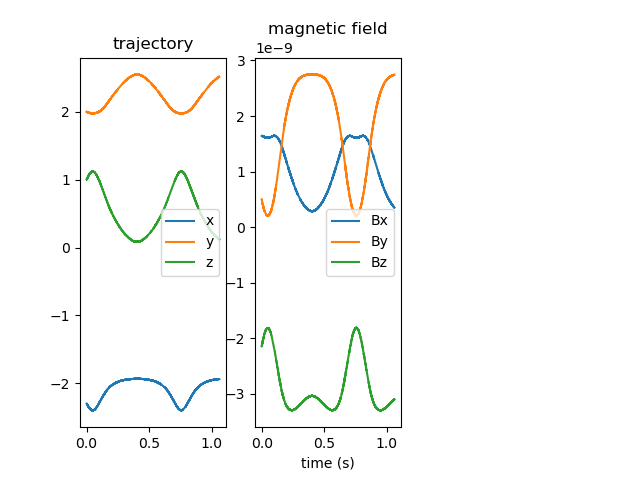

Text(0.5, 1.0, 'mirror force')

In [180]:
# plot the particles position, magnetic field, and mirror force over time
plt.figure(2)
plt.clf()
plt.subplot(1,3,2)
plt.plot(np.arange(particle_position_x.size)*1e-5,B_traj[:,0],label='Bx')
plt.plot(np.arange(particle_position_x.size)*1e-5,B_traj[:,1],label='By')
plt.plot(np.arange(particle_position_x.size)*1e-5,B_traj[:,2],label='Bz')
plt.title('magnetic field')
plt.xlabel('time (s)')
plt.legend()
plt.subplot(1,3,1)
plt.plot(np.arange(particle_position_x.size)*1e-5,particle_position_x,label='x')
plt.plot(np.arange(particle_position_x.size)*1e-5,particle_position_y,label='y')
plt.plot(np.arange(particle_position_x.size)*1e-5,particle_position_z,label='z')
plt.title('trajectory')
plt.legend()
plt.show()
plt.subplot(1,3,3)
plt.plot(np.arange(particle_position_x.size-1)*1e-5,F_mirror)
plt.title('mirror force')

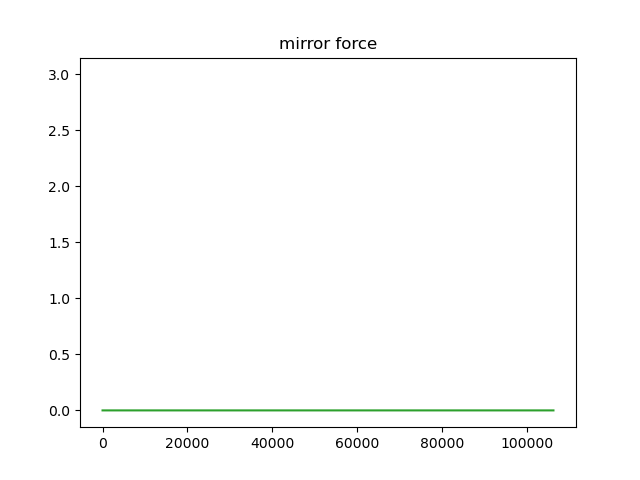

In [175]:
plt.figure(21)
plt.clf()
plt.plot(1,3,3)
plt.plot(np.arange(particle_position_x.size-1),F_mirror)
plt.title('mirror force')
plt.show()

Text(0.5, 1.0, 'Bz')

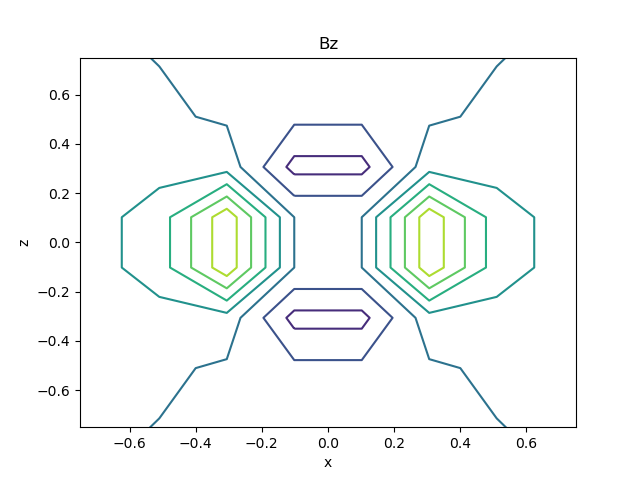

In [152]:
# sanity check: plot contours of dipole magnetic field
xx=np.linspace(gridstart,gridend,gridlength)
yy=np.linspace(gridstart,gridend,gridlength)
zz=np.linspace(gridstart,gridend,gridlength)
plt.figure()
plt.contour(xx,zz,Bz[:,gridlength//2,:].value) # side view of dipole
plt.xlim(-.75,.75)
plt.ylim(-.75,.75)
plt.xlabel('x')
plt.ylabel('z')
plt.title('Bz')

Text(0.5, 0.92, 'x0= [[1. 0. 0.]] m, v0 = [[0.   0.01 0.  ]] m / s, t=0.1 s')

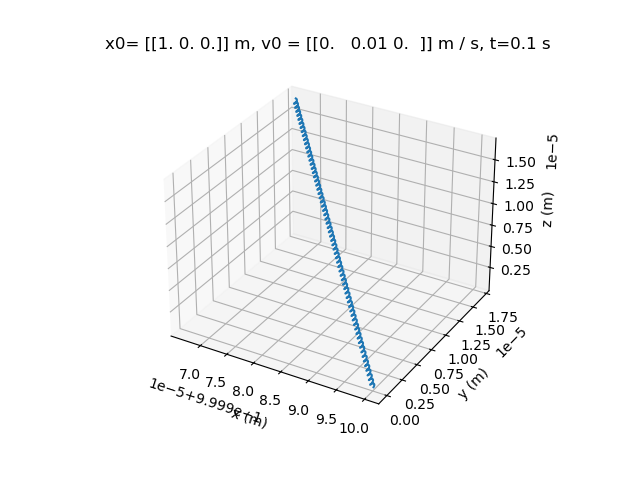

In [11]:
# sanity check/maybe the only reasonable result to come out of this: a run that shows gyromotion
termination_condition = TimeElapsedTerminationCondition(.01*u.s)
save_routine = IntervalSaveRoutine(1e-7*u.s)
simulation = ParticleTracker(
    grid, save_routine=save_routine,
    termination_condition=termination_condition,
    verbose=False,
)

x0=[[1, 0, 0]]*u.m
v0=[[0,.01,0]]*u.m/u.s
particle = Particle("e-")
simulation.load_particles(x0, v0, particle)
simulation.run()

results = save_routine.results
particle_trajectory = results["x"][:, 0]
particle_position_x = particle_trajectory[:, 0]
particle_position_y = particle_trajectory[:, 1]
particle_position_z = particle_trajectory[:, 2]

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot(particle_position_x, particle_position_y,particle_position_z)
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_zlabel('z (m)')
plt.title(f'x0= {x0}, v0 = {v0}, t=0.1 s')